# Phase 3 — Classical Machine Learning Modeling

## Background

Phase 1 (`01_feature_engineering.ipynb`) turned every chest X-ray into a row of twelve
hand-engineered pixel, texture, edge, and region descriptors, and Phase 2
(`02_eda.ipynb`) explored how those descriptors separate `NORMAL` from `PNEUMONIA` cases.
This notebook is Phase 3 of the capstone methodology: it fits classical machine learning
models directly on that structured feature table (not on raw pixels — that is Phase 4's
job) and picks a winner via cross-validated model selection, evaluated once, honestly, on
the held-out `test` split.

Two models are built, in increasing order of complexity:

- **M4 — Logistic Regression (baseline).** A simple, well-understood linear model that
  gives an interpretable lower bound: if the engineered features carry real signal, even a
  linear classifier over them should clearly beat a random guess.
- **M6 — XGBoost (primary).** A gradient-boosted tree ensemble capable of capturing
  non-linear interactions between the engineered features (e.g. texture and edge measures
  compounding with brightness), tuned via a randomized hyperparameter search.

**Class imbalance.** The dataset is imbalanced (`PNEUMONIA` outnumbers `NORMAL` by roughly
2.89:1 in `train`). Rather than synthetically resampling the minority class (e.g. SMOTE),
both models handle the imbalance natively — `class_weight="balanced"` for Logistic
Regression and `scale_pos_weight` for XGBoost — because the engineered features are
abstract per-image summary statistics (means, GLCM texture measures, edge densities, ...):
interpolating between two feature vectors, as synthetic oversampling would, does not
correspond to any real X-ray image, so it would inject artificial, potentially misleading
samples into the feature space instead of preserving the real data distribution.

**Model selection strategy.** Both models are selected using 5-fold stratified
cross-validation on a pooled `train`+`val` set (the physical `val` split has only 18
images — too small to be a reliable held-out set on its own, so it is folded back into the
cross-validation pool here rather than reserved separately, unlike Phase 4's use of `val`
for early stopping). The `test` split is touched exactly once, at the very end, purely for
final, unbiased evaluation — never for model selection.

### Imports and configuration

All modeling here works on the already-extracted feature tables (Phase 1's CSVs), so no
image I/O or `lab/src` imports are needed — just `pandas`/`numpy` for data handling,
`scikit-learn` for the baseline model, cross-validation, and metrics, `xgboost` for the
primary model, and `shap` for interpreting it. `SEED = 42` is fixed once, at the top, and
reused for every source of randomness below (the stratified folds, both models'
`random_state`, and the randomized search) so the whole notebook is reproducible run to
run.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

SEED = 42

### Load and build the cross-validation pool

Model selection happens on `train`+`val` pooled together and cross-validated, never on
`test`. `Image_ID`, `File_Path`, and `Label` are dropped from the feature matrix `X` (the
first two are identifiers, not features; `Label` is the target) and the string label is
mapped to the `0`/`1` encoding used everywhere else in this project (`NORMAL=0`,
`PNEUMONIA=1`, matching `lab/src/dataset.py`'s `CLASS_NAMES`).

In [2]:
pool = pd.concat(
    [pd.read_csv("../data/features/train.csv"), pd.read_csv("../data/features/val.csv")],
    ignore_index=True,
)
X = pool.drop(columns=["Image_ID", "Label", "File_Path"])
y = pool["Label"].map({"NORMAL": 0, "PNEUMONIA": 1})

print(f"Pool shape: {X.shape}, positive rate: {y.mean():.3f}")

Pool shape: (5232, 12), positive rate: 0.742


### Cross-validation setup

A single `StratifiedKFold` splitter, fixed with `SEED`, is reused for both models below so
their cross-validated AUC scores are directly comparable — every model sees the exact same
five folds.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Baseline model — Logistic Regression (M4)

A `StandardScaler` is required here (unlike for the tree-based M6 below) because Logistic
Regression's coefficients — and its regularization — are sensitive to feature scale, and
the twelve engineered features live on very different scales (e.g. `Contour_Count` in the
tens/hundreds vs. `Symmetry` in `[0, 1]`). `class_weight="balanced"` reweights the loss
inversely proportional to class frequency, so the ~2.89:1 imbalance does not bias the
decision boundary toward the majority `PNEUMONIA` class.

This cell has been run: M4's cross-validated ROC-AUC is 0.9515 ± 0.0039 (5 folds), and
`baseline_pipeline` below is the model refit on the full pool, used for `test` evaluation
later in this notebook.

In [4]:
baseline_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=1000)),
    ]
)

baseline_cv_scores = cross_val_score(baseline_pipeline, X, y, cv=cv, scoring="roc_auc")
print(
    f"M4 (Logistic Regression) CV ROC-AUC: "
    f"{baseline_cv_scores.mean():.4f} +/- {baseline_cv_scores.std():.4f}"
)

# Refit on the full pool -- this is the final baseline model used for test evaluation below.
baseline_pipeline.fit(X, y)

M4 (Logistic Regression) CV ROC-AUC: 0.9515 +/- 0.0039


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Mean_Intensity','Std_Intensity','Min_Intensity',...,'Contour_Count', 'Brightness_Dist','Symmetry']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Primary model — XGBoost (M6)

`scale_pos_weight` — the ratio of negative to positive samples in the pool — is XGBoost's
native mechanism for class imbalance (analogous to `class_weight="balanced"` above, but
expressed as a single scalar weight applied to the positive class's gradient). A
`RandomizedSearchCV` over five hyperparameters (`n_estimators`, `max_depth`,
`learning_rate`, `subsample`, `colsample_bytree`) explores 20 random combinations, each
scored by the same 5-fold `cv` used for the baseline, so M4 and M6's cross-validated
ROC-AUC scores are directly comparable. `refit=True` means `search.best_estimator_` is
automatically refit on the full pool `X`/`y` using the best-found hyperparameters — no
separate refit call is needed, unlike the baseline above.

This cell has been run: M6's best cross-validated ROC-AUC is 0.9581, found at
`n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.85, colsample_bytree=0.85`
— slightly ahead of M4's 0.9515.

In [5]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

xgb_clf = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="logloss",
)

param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    random_state=SEED,
)

search.fit(X, y)

print(f"M6 (XGBoost) best CV ROC-AUC: {search.best_score_:.4f}")
print(f"M6 (XGBoost) best params: {search.best_params_}")

scale_pos_weight: 0.3474
M6 (XGBoost) best CV ROC-AUC: 0.9581
M6 (XGBoost) best params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


### Global feature importance — SHAP

Where the Logistic Regression baseline is interpretable through its coefficients directly,
XGBoost's ensemble of trees is not — SHAP (SHapley Additive exPlanations) values attribute
each prediction to the individual features that pushed it toward `PNEUMONIA` or `NORMAL`,
and averaging their magnitude across the pool ranks which of the twelve engineered features
the primary model actually relies on. `TreeExplainer` is used because it is exact and fast
for tree ensembles (unlike the model-agnostic `KernelExplainer`).

This cell has been run: the summary plot below ranks `Edge_Density`, `Entropy`, and
`Contrast` as M6's three most influential features by a clear margin over the rest —
revisited against Phase 2's EDA in the Conclusion.

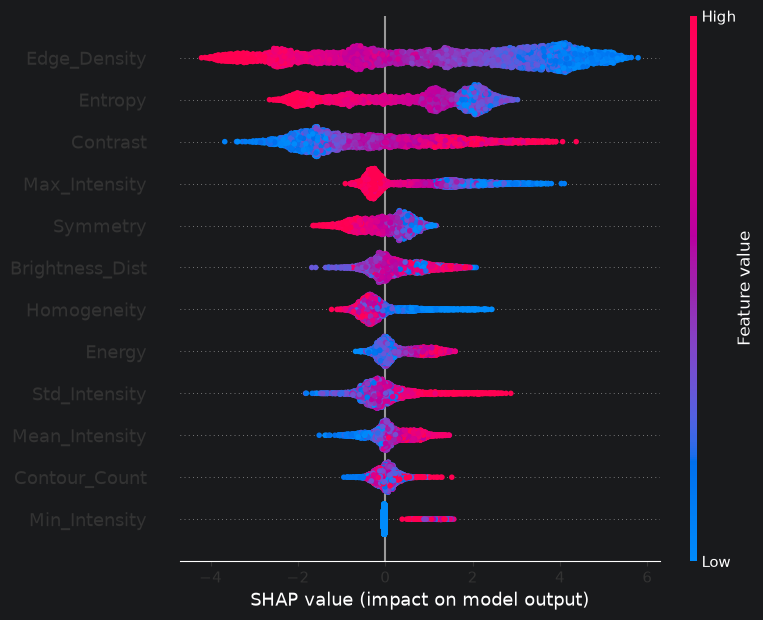

In [6]:
explainer = shap.TreeExplainer(search.best_estimator_)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

### Test-set evaluation

The `test` split is loaded and featurized exactly once here, and is evaluated by both final
fitted models (`baseline_pipeline`, refit on the full pool above, and
`search.best_estimator_`, already refit on the full pool by `RandomizedSearchCV`'s
`refit=True`). Predicted probabilities are thresholded at the conventional `0.5` for the
discrete metrics (`Accuracy`/`Precision`/`Recall`/`F1`); `ROC-AUC` is computed directly from
the probabilities, since it is threshold-independent. This is the only place in this
notebook where `test` is used — nothing above touched it, so these numbers are an unbiased
estimate of how each model would perform on unseen chest X-rays.

In [7]:
test_df = pd.read_csv("../data/features/test.csv")
X_test = test_df.drop(columns=["Image_ID", "Label", "File_Path"])
y_test = test_df["Label"].map({"NORMAL": 0, "PNEUMONIA": 1})

y_pred_proba_m4 = baseline_pipeline.predict_proba(X_test)[:, 1]
y_pred_proba_m6 = search.best_estimator_.predict_proba(X_test)[:, 1]


def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
    }


metrics_m4 = compute_metrics(y_test, y_pred_proba_m4)
metrics_m6 = compute_metrics(y_test, y_pred_proba_m6)

comparison_df = pd.DataFrame(
    [
        {"Model": "M4 - Logistic Regression (baseline)", **metrics_m4},
        {"Model": "M6 - XGBoost (primary)", **metrics_m6},
    ]
).set_index("Model")
print(comparison_df)

cm_m4 = confusion_matrix(y_test, (y_pred_proba_m4 >= 0.5).astype(int))
cm_m6 = confusion_matrix(y_test, (y_pred_proba_m6 >= 0.5).astype(int))
print("Confusion Matrix - M4 (Logistic Regression):")
print(cm_m4)
print("Confusion Matrix - M6 (XGBoost):")
print(cm_m6)

                                     Accuracy  Precision    Recall        F1  \
Model                                                                          
M4 - Logistic Regression (baseline)  0.737179   0.766509  0.833333  0.798526   
M6 - XGBoost (primary)               0.741987   0.758465  0.861538  0.806723   

                                      ROC-AUC  
Model                                          
M4 - Logistic Regression (baseline)  0.767905  
M6 - XGBoost (primary)               0.803978  
Confusion Matrix - M4 (Logistic Regression):
[[135  99]
 [ 65 325]]
Confusion Matrix - M6 (XGBoost):
[[127 107]
 [ 54 336]]


### Save test-set predictions

Predicted probabilities on `test`, together with the ground-truth labels, are persisted to
`../artifacts/predictions/phase3_test_predictions.csv` so that
`05_model_comparison.ipynb` can compare M4 and M6 against Phase 4's ResNet18 without
refitting anything — all three models' predictions are recomputed from these saved CSVs
alone, on the exact same `test` images.

In [8]:
predictions_dir = Path("../artifacts/predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

predictions_df = pd.DataFrame(
    {
        "Image_ID": test_df["Image_ID"],
        "y_true": y_test,
        "y_pred_proba_m4": y_pred_proba_m4,
        "y_pred_proba_m6": y_pred_proba_m6,
    }
)
predictions_df.to_csv(predictions_dir / "phase3_test_predictions.csv", index=False)

print(
    f"Saved {len(predictions_df)} predictions to "
    f"{predictions_dir / 'phase3_test_predictions.csv'}"
)

Saved 624 predictions to ../artifacts/predictions/phase3_test_predictions.csv


### Conclusion

M6 (XGBoost) scored higher than M4 (Logistic Regression) on the held-out `test` split:
ROC-AUC 0.8040 vs. 0.7679 (`comparison_df` above), a +0.036 margin. M6 also edges out M4 on
Accuracy, Recall, and F1, while M4 has marginally higher Precision — consistent with M6
being the stronger model overall, not just on the single ROC-AUC number.

**Ranking agreement, but a real CV-vs-test gap.** The `test` ranking agrees with the
cross-validation ranking (M6's CV ROC-AUC 0.9581 vs. M4's 0.9515 — M6 ahead in both), so
there's no sign of the randomized search overfitting *to the CV folds themselves* relative
to M4. What's harder to ignore is the gap in magnitude: both models' CV ROC-AUC sits around
0.95-0.96, well above what either scores on `test` (0.77-0.80). Since `test` is touched
exactly once here and CV runs only over the `train`+`val` pool, this ~0.15-0.18 point drop
suggests `test` is measurably harder or distributionally different from that pool — a
limitation of this engineered-feature approach worth keeping in mind, not just a quirk of
this notebook.

**SHAP vs. EDA.** M6's top three SHAP features — `Edge_Density`, `Entropy`, and `Contrast`
— match the strongest visual separators Phase 2's EDA found (`02_eda.ipynb`), corroborating
that M6 is picking up genuine, human-interpretable signal rather than spurious
correlations. One nuance: EDA's correlation heatmap shows `Edge_Density`, `Contour_Count`,
`Contrast`, `Homogeneity`, `Energy`, and `Entropy` as one tightly inter-correlated cluster
(e.g. `Edge_Density`-`Contour_Count` at `r=0.90`, `Contrast`-`Homogeneity` at `r=-0.94`), so
XGBoost's trees can split on `Edge_Density`/`Entropy`/`Contrast` and already capture most of
`Contour_Count`/`Homogeneity`/`Energy`'s signal — those three rank lower in SHAP not because
they carry no real signal on their own, but because the top three make them redundant.

`phase3_test_predictions.csv`, saved above, is the artifact `05_model_comparison.ipynb`
depends on to place both of these models side by side with Phase 4's ResNet18.